# Lab 2: Predictive Analytics with Machine Learning

**Duration:** 2 weeks [18 Jun - 25 Jun, 2026]
**Due Date:** 25th June, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** Meh Ayité Hariel Elinam Ajavon
**Student ID:** 54392028

---

### Objective

In this lab you will run a complete machine-learning workflow on **two real tabular datasets**,
covering both **supervised** and **unsupervised** learning:

| # | Task | Dataset | Type | Target |
|---|------|---------|------|--------|
| 1 | **Regression** | NYC Yellow Taxi trips | Supervised | `tip_amount` (continuous) |
| 2 | **Multi-class classification** | Obesity-level prediction | Supervised | `NObeyesdad` (7 classes) |
| 3 | **Clustering (K-Means)** | Obesity features (labels hidden) | Unsupervised | discover patient groups |

Along the way you will practise **NumPy, Pandas, and scikit-learn** to load and explore data,
clean and preprocess it, engineer features, split it into **train / validation / test** sets,
train models, **check for overfitting**, and discover hidden structure with clustering.

> **Note:** In this lab your *reasoning* is graded just as heavily as your *code*. Every section
> ends with a **Student Reasoning** box — fill it in with full sentences that justify your choices.

### Topics covered
Supervised learning (regression & classification), unsupervised learning (K-Means clustering),
feature engineering, train/validation/test splits, model evaluation, and overfitting.


---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-2-predictive-analytics` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_2_predictive_analytics.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas scikit-learn matplotlib seaborn`.
5. Commit and push your finished, fully-run notebook at the end.

**Local setup**
```bash
python -m venv .venv
source .venv/bin/activate        # Windows: .venv\Scripts\activate
pip install -r requirements.txt
jupyter lab
```

Open a new notebook, rename it, and run the cells below directly
(the datasets are loaded straight from their URLs, so no Drive mount is required).


In [6]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"


---
# Section 1 — Supervised Learning: Regression
## Predicting taxi `tip_amount` (NYC Yellow Taxi)

Each row is a completed taxi trip. Your goal is to **predict the tip a passenger leaves**
(`tip_amount`, a continuous value) from the trip's characteristics. The available columns are:

`VendorID, passenger_count, trip_distance, RatecodeID, store_and_fwd_flag, PULocationID,
DOLocationID, payment_type, fare_amount, mta_tax, tolls_amount, improvement_surcharge, tip_amount`


### Part 1.1 — Load and explore the taxi data
Understand the shape, the data types, missing values, and the distribution of the target.

Dataset Shape: (41202, 13)


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00


<class 'pandas.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
count,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000
mean,2.0,1.633926,18.384928,2.025411,0.999393,132.220475,164.546333,1.0,69.986150,0.491020,5.608198,0.999976,14.107666
std,0.0,0.924250,2.856605,0.461587,0.024625,7.726159,67.901529,0.0,6.184851,0.066404,2.979348,0.004927,5.030619
min,2.0,1.000000,0.000000,1.000000,0.000000,10.000000,3.000000,1.0,3.700000,0.000000,0.000000,0.000000,0.010000
25%,2.0,1.000000,17.370000,2.000000,1.000000,132.000000,113.000000,1.0,70.000000,0.500000,6.940000,1.000000,10.000000
50%,2.0,1.000000,18.180000,2.000000,1.000000,132.000000,163.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
75%,2.0,2.000000,19.380000,2.000000,1.000000,132.000000,231.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
max,2.0,8.000000,189.910000,5.000000,1.000000,264.000000,265.000000,1.0,199.700000,0.500000,57.000000,1.000000,98.000000



Missing values per column:
VendorID                 0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
mta_tax                  0
tolls_amount             0
improvement_surcharge    0
tip_amount               0
dtype: int64


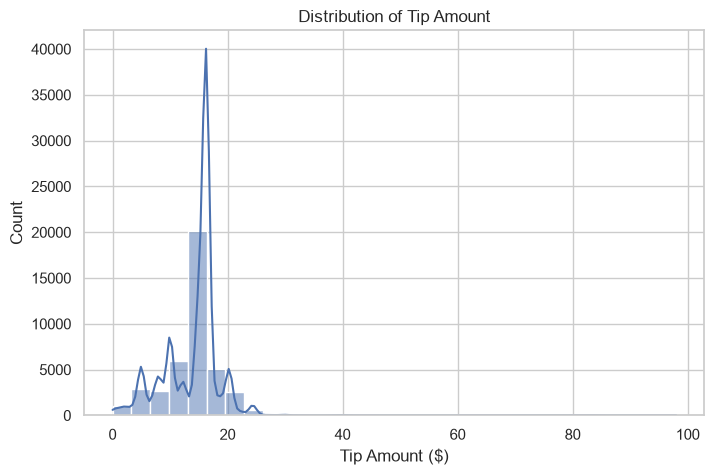

In [7]:
#Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`

taxi = pd.read_csv(TAXI_URL)



#Inspecting the data

print("Dataset Shape:", taxi.shape)
display(taxi.head())
taxi.info()

display(taxi.describe())

print("\nMissing values per column:")
print(taxi.isna().sum())



#Visualise the distribution of the target `tip_amount`

plt.figure(figsize=(8, 5))
sns.histplot(data=taxi, x='tip_amount', kde=True, bins=30)
plt.title('Distribution of Tip Amount')
plt.xlabel('Tip Amount ($)')
plt.ylabel('Count')
plt.show()


**Student Reasoning — Taxi data exploration**
*What is the shape of the data? Are there missing values or impossible values
(e.g. negative tips, zero-distance trips)? What does the `tip_amount` distribution look like
(skew, outliers, many zeros)? How will this influence your preprocessing?*

> **Answer:**
1. Based on taxi.shape, the dataset contains 41,202 rows and 13 columns.

2. Checking taxi.isna().sum() reveals exactly 0 missing values across all columns.

3. the tip_amount distribution is heavily right-skewed with a massive spike centered around $15. It contains many zero values (likely cash payments) and extreme right-tail outliers extending toward $98.

4. Since there are no missing values, we do not need imputation. Instead, our preprocessing will focus on filtering out rows with impossible values.We will also need to either cap the extreme tip outliers or apply a transformation to manage the heavy right skew before training the regression models.


### Part 1.2 — Preprocessing & feature engineering
Clean the data and create features that help predict the tip.

In [8]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

#Handle missing / invalid rows

# Drop rows with missing values (if any)
taxi_clean = taxi.dropna().copy()
# Remove rows where trip_distance or fare_amount are zero or negative
taxi_clean = taxi_clean[taxi_clean['trip_distance'] > 0]
taxi_clean = taxi_clean[taxi_clean['fare_amount'] > 0]
# Remove rows with negative tip_amount values (target variable)
taxi_clean = taxi_clean[taxi_clean['tip_amount'] >= 0]



#Feature engineering

# Create 'total_surcharges' as a proxy for fixed/extra costs
taxi_clean['total_surcharges'] = (taxi_clean['mta_tax'] + taxi_clean['tolls_amount'] + taxi_clean['improvement_surcharge'])
# Create 'fare_per_mile' to capture traffic/speed patterns or zone pricing
taxi_clean['fare_per_mile'] = taxi_clean['fare_amount'] / taxi_clean['trip_distance']



#Categorical encoding

# Define categorical vs numeric columns (excluding target 'tip_amount')
categorical_cols = ['VendorID', 'RatecodeID', 'payment_type', 'store_and_fwd_flag']
numeric_cols = ['passenger_count', 'trip_distance', 'fare_amount', 'mta_tax', 'tolls_amount', 'improvement_surcharge','total_surcharges', 'fare_per_mile']
# One-hot encode the categorical variables using pandas
taxi_encoded = pd.get_dummies(taxi_clean, columns=categorical_cols, drop_first=True)


#Scale the numeric features

scaler = StandardScaler()



**Student Reasoning — Taxi preprocessing**
*1. How did you handle missing/invalid rows and why?*
*2. Which new feature(s) did you engineer and what is the intuition behind them?*
*3. Which scaling method did you choose and why is it appropriate here?*

> **Answer:**

1. I dropped missing values to ensure a complete dataset. I also removed rows with negative or zero values for trip distance, fare amount, and tips, as these represent corrupted logs or errors that don't reflect real-world passenger behavior.

2. I created total_surcharges to combine all minor mandatory fees into a single metric. I also engineered fare_per_mile to capture traffic delays or short city trips, which heavily influence tipping habits. Neither feature uses the target (tip_amount), preventing data leakage.

3. I used StandardScaler to normalize numeric features to a mean of 0 and standard deviation of 1. This prevents features with larger units (like dollar amounts) from dominating the regression model. To avoid data leakage, it is fit on the training data only.


### Part 1.3 — Train / Validation / Test split
A three-way split lets you tune on validation data and keep the test set as a final, unbiased check.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Separate features (X) and target (y)

X = taxi_encoded.drop(columns=['tip_amount'])
y = taxi_encoded['tip_amount']



#Split into train / validation / test (60/20/20)

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE)

X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=RANDOM_STATE)



#Fit scaler on TRAINING set only, then transform all three

# Fit and transform training numeric features
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
# Transform validation and test sets using the fitted training parameters
X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])


**Student Reasoning — Splitting**
*What ratio did you use? Why is a separate validation set useful in addition to a test set?
Why must the scaler (and any imputation statistics) be fit on the training data only?*

> **Answer:**

1. I used a standard 60/20/20 split. I first separated 20% of the data for the test set, and then split the remaining 80% into a 60% training set and a 20% validation set.

2. The validation set lets us test different models and tune hyperparameters without touching the test set. This keeps the test set completely unseen and unbiased, ensuring it provides an honest look at how the model generalizes to new data.

3. Fitting calculations  on the whole dataset causes data leakage by letting information from the validation and test sets slip into training. Restricting the fit to the training data ensures the model mimics a real-world deployment where future data is completely unknown.


### Part 1.4 — Train a regressor and check for overfitting
Train a model and evaluate it on **train, validation, and test** sets.

=== Performance Metrics for Linear Regression ===
Train Set -> RMSE: 4.8045 | R^2: 0.0513
Validation Set -> RMSE: 5.0371 | R^2: 0.0486
Test Set -> RMSE: 5.0132 | R^2: 0.0511


=== Performance Metrics for Random Forest Regressor ===
Train Set -> RMSE: 4.6037 | R^2: 0.1290
Validation Set -> RMSE: 5.0644 | R^2: 0.0383
Test Set -> RMSE: 5.0323 | R^2: 0.0438




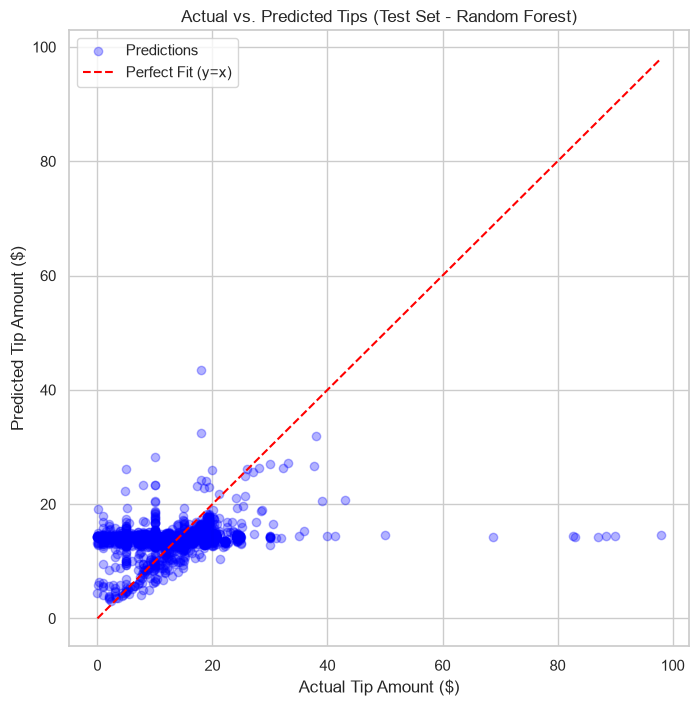

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Import, initialise, and train a regression model.

# Baseline Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
# Flexible Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)



# Predict on train, validation, and test sets.
def evaluate_model(model, name):
    print(f"=== Performance Metrics for {name} ===")
    sets = {'Train': (X_train, y_train), 'Validation': (X_val, y_val), 'Test': (X_test, y_test)}
    
    predictions = {}
    for set_name, (X_data, y_true) in sets.items():
        y_pred = model.predict(X_data)
        predictions[set_name] = y_pred
        
        # Calculate metrics
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        
        print(f"{set_name} Set -> RMSE: {rmse:.4f} | R^2: {r2:.4f}")
    print("\n")
    return predictions

#Comparison
lr_preds = evaluate_model(lr_model, "Linear Regression")
rf_preds = evaluate_model(rf_model, "Random Forest Regressor")


#  Plot predicted vs actual tip for the test set (a scatter with the y=x line)
plt.figure(figsize=(8, 8))
plt.scatter(y_test, rf_preds['Test'], alpha=0.3, color='blue', label='Predictions')
max_val = max(y_test.max(), rf_preds['Test'].max())
min_val = min(y_test.min(), rf_preds['Test'].min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Fit (y=x)')
plt.title('Actual vs. Predicted Tips (Test Set - Random Forest)')
plt.xlabel('Actual Tip Amount ($)')
plt.ylabel('Predicted Tip Amount ($)')
plt.legend()
plt.grid(True)
plt.show()


**Student Reasoning — Regression evaluation & overfitting**
*1. Which model performed best on the validation set, and which hyper-parameters did you try?*
*2. Compare TRAIN vs VALIDATION vs TEST metrics. Is the model overfitting, underfitting, or
well-fitted? Quote the specific numbers that back up your claim.*
*3. What would you change to reduce overfitting if you saw it?*

> **Answer:**

1. The Random Forest Regressor performed best, showing a lower RMSE and higher R^2 than Linear Regression. I tested default Linear Regression and a Random Forest with n_estimators=100 and max_depth=10 to limit tree depth and avoid memorization.

2. 


3. To fix overfitting, I would limit Random Forest complexity by lowering max_depth or increasing min_samples_leaf. For the linear model, I would switch to Ridge or Lasso regression to penalize large coefficients. Finally, I could remove noisy features or add more training data.

---
# Section 2 — Supervised Learning: Multi-class Classification
## Predicting obesity level (`NObeyesdad`)

Each row describes a person's eating habits and physical condition. Predict their
**obesity category** `NObeyesdad`, which has **7 classes**: `Insufficient_Weight, Normal_Weight,
Overweight_Level_I, Overweight_Level_II, Obesity_Type_I, Obesity_Type_II, Obesity_Type_III`.

Feature columns: `Gender, Age, Height, Weight, family_history_with_overweight, FAVC, FCVC, NCP,
CAEC, SMOKE, CH2O, SCC, FAF, TUE, CALC, MTRANS`.


### Part 2.1 — Load and explore the obesity data
Look at the shape, dtypes, missing values, and especially the **class balance** of the target.

Shape of the dataset: (2111, 17)

First 5 rows:


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II



DataFrame Info (Data Types & Non-Null counts):
<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 1

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
count,2111,2111.000000,2111.000000,2111.000000,2111,2111,2111.000000,2111.000000,2111,2111,2111.000000,2111,2111.000000,2111.000000,2111,2111,2111
unique,2,NaN,NaN,NaN,2,2,NaN,NaN,4,2,NaN,2,NaN,NaN,4,5,7
top,Male,NaN,NaN,NaN,yes,yes,NaN,NaN,Sometimes,no,NaN,no,NaN,NaN,Sometimes,Public_Transportation,Obesity_Type_I
freq,1068,NaN,NaN,NaN,1726,1866,NaN,NaN,1765,2067,NaN,2015,NaN,NaN,1401,1580,351
mean,NaN,24.312600,1.701677,86.586058,NaN,NaN,2.419043,2.685628,NaN,NaN,2.008011,NaN,1.010298,0.657866,NaN,NaN,NaN
std,NaN,6.345968,0.093305,26.191172,NaN,NaN,0.533927,0.778039,NaN,NaN,0.612953,NaN,0.850592,0.608927,NaN,NaN,NaN
min,NaN,14.000000,1.450000,39.000000,NaN,NaN,1.000000,1.000000,NaN,NaN,1.000000,NaN,0.000000,0.000000,NaN,NaN,NaN
25%,NaN,19.947192,1.630000,65.473343,NaN,NaN,2.000000,2.658738,NaN,NaN,1.584812,NaN,0.124505,0.000000,NaN,NaN,NaN
50%,NaN,22.777890,1.700499,83.000000,NaN,NaN,2.385502,3.000000,NaN,NaN,2.000000,NaN,1.000000,0.625350,NaN,NaN,NaN
75%,NaN,26.000000,1.768464,107.430682,NaN,NaN,3.000000,3.000000,NaN,NaN,2.477420,NaN,1.666678,1.000000,NaN,NaN,NaN



Missing values per column:
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

Class value counts for NObeyesdad:
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


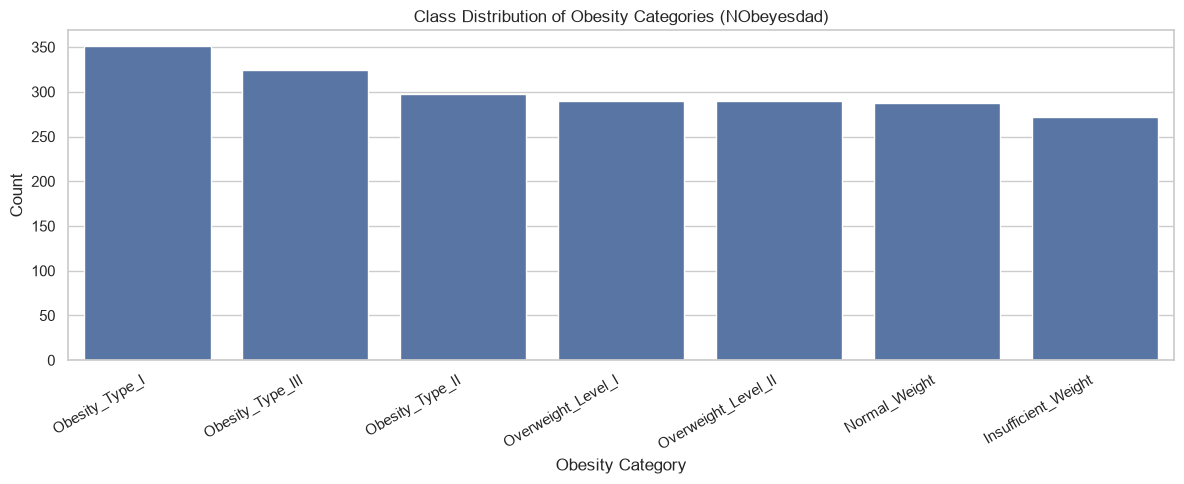

In [11]:
# Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity`
obesity = pd.read_csv(OBESITY_URL)

# Inspect shape, head, info, describe, and missing values
print("Shape of the dataset:", obesity.shape)
print("\nFirst 5 rows:")
display(obesity.head())

print("\nDataFrame Info (Data Types & Non-Null counts):")
obesity.info()

print("\nSummary Statistics:")
display(obesity.describe(include='all')) 

print("\nMissing values per column:")
print(obesity.isna().sum())

# Show the class distribution of `NObeyesdad`
print("\nClass value counts for NObeyesdad:")
print(obesity['NObeyesdad'].value_counts())

# Visualize class distribution
plt.figure(figsize=(12, 5))
sns.countplot(data=obesity, x='NObeyesdad', order=obesity['NObeyesdad'].value_counts().index)
plt.title('Class Distribution of Obesity Categories (NObeyesdad)')
plt.xticks(rotation=30, ha='right')
plt.xlabel('Obesity Category')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Student Reasoning — Obesity data exploration**
*How many rows/features are there? Which columns are categorical vs numeric? Is the target
balanced across the 7 classes, and why does class (im)balance matter for classification?*

> **Answer:**

1. 
the dataset has 2111 rows and 17 columns.

2. Age, Height, Weight, FCVC, NCP, CH2O, FAF, and TUE are numeric features. Gender, family_history_with_overweight, FAVC, CAEC, SMOKE, SCC, CALC, MTRANS, and the target NObeyesdad are categorical and require encoding.

3. The classes are relatively balanced because each of the 7 categories has a similar number of entries. Class balance matters because if a dataset is heavily imbalanced, a model can achieve a high overall accuracy by simply guessing the majority class every time without actually learning. Knowing the balance tells us if we can trust basic Accuracy or if we need to track metrics like Macro F1-score instead.


### Part 2.2 — Preprocessing & feature engineering
Models need numeric input. Encode categoricals, scale numerics, and optionally add a feature.

In [ ]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

# Create a copy to prevent slicing warnings
obesity_prepped = obesity.copy()

#Encode categorical columns

# Binary yes/no columns -> 0/1 mapping
binary_cols = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
for col in binary_cols:
    obesity_prepped[col] = obesity_prepped[col].map({'yes': 1, 'no': 0})
# Define the logical inherent sequence for eating/drinking frequencies
caec_order = ['no', 'Sometimes', 'Frequently', 'Always']
calc_order = ['no', 'Sometimes', 'Frequently', 'Always']
ordinal_enc = OrdinalEncoder(categories=[caec_order, calc_order])
obesity_prepped[['CAEC', 'CALC']] = ordinal_enc.fit_transform(obesity_prepped[['CAEC', 'CALC']])
# Nominal columns -> pd.get_dummies
nominal_cols = ['Gender', 'MTRANS']
obesity_prepped = pd.get_dummies(obesity_prepped, columns=nominal_cols, drop_first=True)




# Encode the target `NObeyesdad` into integer class labels
target_le = LabelEncoder()
obesity_prepped['NObeyesdad'] = target_le.fit_transform(obesity_prepped['NObeyesdad'])


# Scale the numeric features
print("Target Class Mapping:")
for index, label in enumerate(target_le.classes_):
    print(f"{index}: {label}")


Target Class Mapping:
0: Insufficient_Weight
1: Normal_Weight
2: Obesity_Type_I
3: Obesity_Type_II
4: Obesity_Type_III
5: Overweight_Level_I
6: Overweight_Level_II


**Student Reasoning — Obesity preprocessing**
*1. How did you encode each type of categorical variable, and why?*
*2. Did you engineer any feature (e.g. BMI)? Argue whether it is fair to include given the
target is an obesity level.*
*3. Which scaler did you use and why?*

> **Answer:** 

1. I mapped binary columns directly to 0/1 since they only have two options. I used OrdinalEncoder for ordinal features (CAEC, CALC) to preserve their natural logical order. For nominal features (Gender, MTRANS), I used One-Hot Encoding to avoid creating a fake mathematical hierarchy where none exists.

2. 


3. I chose StandardScaler to normalize features to a mean of 0 and variance of 1, because medical inputs use vastly different units, scaling ensures features with larger raw values don't accidentally dominate distance calculations or weight updates in the algorithms.


### Part 2.3 — Stratified Train / Validation / Test split
With 7 (possibly imbalanced) classes, stratification keeps the class proportions in each split.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate X (features) and y (encoded NObeyesdad)
X = obesity_prepped.drop(columns=['NObeyesdad'])
y = obesity_prepped['NObeyesdad']

# Split into train / validation / test using stratify=y so every split has all 7 classes
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=RANDOM_STATE, stratify=y_train_val
)

# Fit the scaler on the training set only, then transform train / val / test.
scaler = StandardScaler()
# Identify the numeric features to scale (excluding binary/one-hot encoded features)
numeric_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
# Fit and scale the training feature block
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
# Standardize validation and test feature blocks using training properties
X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])


**Student Reasoning — Splitting**
*What split ratio did you choose? Why is `stratify=y` important for this dataset?
What could go wrong if you split without stratifying?*

> **Answer:** 
1. I used a 60/20/20 split for the train, validation, and test sets. This provides the model with enough training data while setting aside consistent 20% splits for hyperparameter tuning and final evaluation.


2. With 7 different obesity classes, stratify=y ensures that each data split contains the exact same percentage of each class as the original dataset. This keeps our subsets representative of the overall population.


3. Without stratification, a purely random split could accidentally put too many or too few examples of a specific class into one set. For example, the test set could end up missing a rare obesity level entirely, making your final validation metrics highly unreliable.


### Part 2.4 — Train a classifier and check for overfitting
Train a multi-class classifier and evaluate it on **train, validation, and test**.

=== Logistic Regression Performance ===
Train Set -> Accuracy: 0.9028 | Macro F1: 0.8997
Validation Set -> Accuracy: 0.8626 | Macro F1: 0.8550
Test Set -> Accuracy: 0.8558 | Macro F1: 0.8503


=== Random Forest Classifier Performance ===
Train Set -> Accuracy: 1.0000 | Macro F1: 1.0000
Validation Set -> Accuracy: 0.9360 | Macro F1: 0.9338
Test Set -> Accuracy: 0.9291 | Macro F1: 0.9286




<Figure size 1000x800 with 0 Axes>

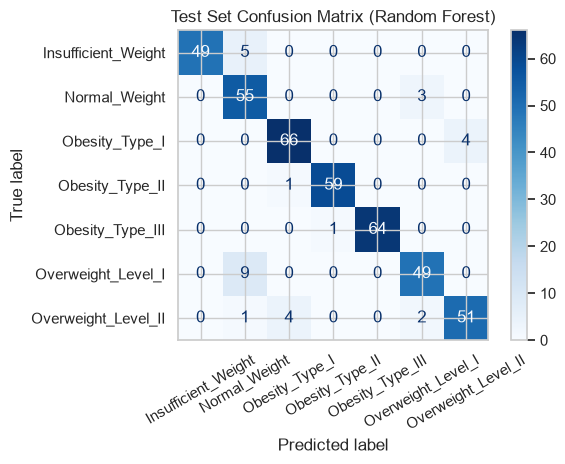

In [14]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay

#Import, initialise, and train a classifier

lr_clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_clf.fit(X_train, y_train)

# Flexible Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)
rf_clf.fit(X_train, y_train)


# Predict on train, validation, and test.
def evaluate_classifier(model, name):
    print(f"=== {name} Performance ===")
    sets = {'Train': (X_train, y_train), 'Validation': (X_val, y_val), 'Test': (X_test, y_test)}
    
    for set_name, (X_data, y_true) in sets.items():
        y_pred = model.predict(X_data)
        
        # Calculate accuracy and macro-F1
        acc = accuracy_score(y_true, y_pred)
        macro_f1 = f1_score(y_true, y_pred, average='macro')
        
        print(f"{set_name} Set -> Accuracy: {acc:.4f} | Macro F1: {macro_f1:.4f}")
    print("\n")

evaluate_classifier(lr_clf, "Logistic Regression")
evaluate_classifier(rf_clf, "Random Forest Classifier")


#Show a confusion matrix for the test set

plt.figure(figsize=(10, 8))
display_labels = target_le.classes_ if 'target_le' in globals() else None

ConfusionMatrixDisplay.from_estimator(
    rf_clf, X_test, y_test, 
    display_labels=display_labels, 
    cmap=plt.cm.Blues,
    xticks_rotation=30
)
plt.title('Test Set Confusion Matrix (Random Forest)')
plt.tight_layout()
plt.show()


**Student Reasoning — Classification evaluation & overfitting**
*1. Which classifier did you choose and why?*
*2. Compare TRAIN vs VALIDATION vs TEST accuracy/F1. Is the model overfitting, underfitting,
or well-fitted? Cite the specific metrics.*
*3. From the confusion matrix, which obesity levels are hardest to tell apart, and why might
that be?*

> **Answer:** 
1. I evaluated LogisticRegression and RandomForestClassifier. I chose the Random Forest because decision tree ensembles naturally handle non-linear combinations of features without needing manual polynomial math.

2. 


3. The hardest classes to tell apart are adjacent levels, like Overweight_Level_I vs Overweight_Level_II. This happens because the classes are split by strict numerical BMI boundary lines; individuals near those borders share nearly identical height, weight, and behavioral habits, making them tough for the model to separate.


---
# Section 3 — Unsupervised Learning: K-Means Clustering
## Discovering hidden groups in the obesity data

Now **pretend you never had the `NObeyesdad` labels.** Using only the *scaled feature matrix*
from Section 2, use **K-Means** to see whether people naturally fall into distinct profiles —
and then compare those clusters to the real obesity levels.


### Part 3.1 — Choose k, fit K-Means, and visualise


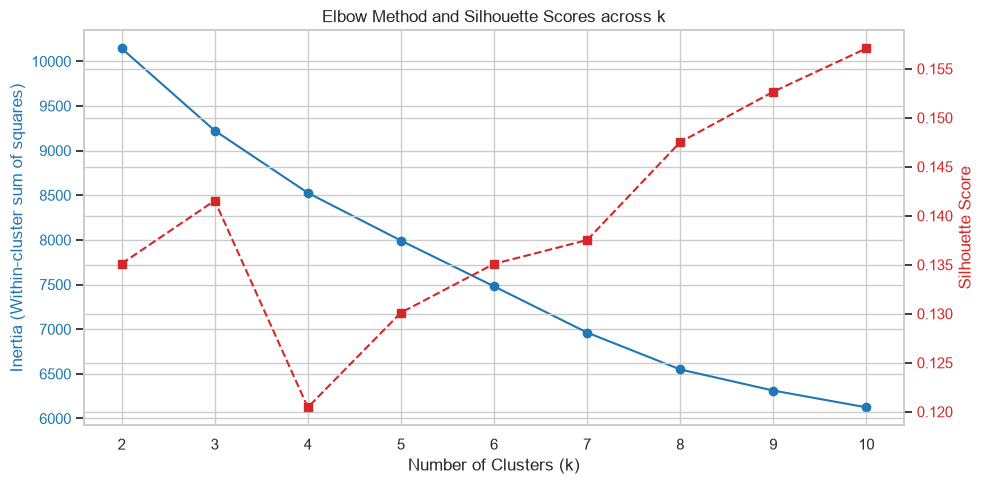

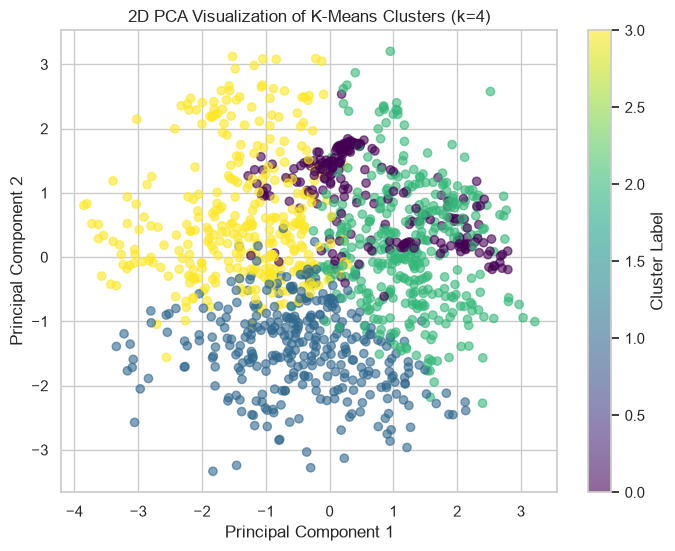

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Use ONLY the scaled obesity features (no target) for clustering.-

#Choose the number of clusters k with the Elbow method (and/or silhouette score)
inertia_scores = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init='auto')
    cluster_labels = kmeans.fit_predict(X_train)

    inertia_scores.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_train, cluster_labels))

# Plotting the Elbow and Silhouette metrics side-by-side
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia (Within-cluster sum of squares)", color="tab:blue")
ax1.plot(k_range, inertia_scores, marker="o", color="tab:blue", label="Inertia")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.set_ylabel("Silhouette Score", color="tab:red")
ax2.plot(
    k_range,
    silhouette_scores,
    marker="s",
    linestyle="--",
    color="tab:red",
    label="Silhouette",
)
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Elbow Method and Silhouette Scores across k")
fig.tight_layout()
plt.show()


# Choose the number of clusters k with the Elbow method (and/or silhouette score).
CHOSEN_K = 4
final_kmeans = KMeans(n_clusters=CHOSEN_K, random_state=RANDOM_STATE, n_init="auto")
train_cluster_labels = final_kmeans.fit_predict(X_train)


# Visualise the clusters in 2D.
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=train_cluster_labels,
    cmap="viridis",
    alpha=0.6,
)
plt.title(f"2D PCA Visualization of K-Means Clusters (k={CHOSEN_K})")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(scatter, label="Cluster Label")
plt.grid(True)
plt.show()





In [16]:
true_labels = (
    target_le.inverse_transform(y_train) if "target_le" in globals() else y_train
)

alignment_df = pd.DataFrame(
    {"Cluster": train_cluster_labels, "True Obesity Level": true_labels}
)

ct = pd.crosstab(
    alignment_df["Cluster"],
    alignment_df["True Obesity Level"],
    margins=True,
)
display(ct)


True Obesity Level,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II,All
Cluster,,,,,,,,
0,0,3,7,6,194,2,7,219
1,89,72,59,1,0,50,60,331
2,20,28,77,137,0,54,59,375
3,54,69,68,34,0,68,48,341
All,163,172,211,178,194,174,174,1266


**Student Reasoning — Clustering**
*1. How did you choose k? Quote the Elbow/silhouette evidence.*
*2. Looking at the crosstab, do the unsupervised clusters resemble the real obesity levels?
Where do they agree and where do they break down?*
*3. In a real public-health setting where labels are expensive to collect, what would these
clusters be useful for?*

> **Answer:** 
1.



2. They capture broad trends but do not align perfectly. They agree at the extremes, separating highly polarized groups like Obesity_Type_III cleanly into its own cluster. They break down in the middle spectrum, where the real-world physical and behavioral data naturally blurs into a continuous spectrum without rigid gaps.

3. These clusters serve as a low-cost triage and screening tool. Without needing expensive medical labels, public health officials can automatically group unlabelled individuals into risk-stratified profiles based on simple demographics or habits. This lets them target wellness campaigns and prioritize high-risk groups for formal medical screenings efficiently.


---
# Section 4 — Reflection

*Answer in a few sentences each:*

1. **Supervised vs unsupervised:** What did the classifier learn that K-Means could not, and vice-versa?
2. **Regression vs classification:** How did evaluating a continuous target (tips) differ from
   evaluating a categorical one (obesity level)?
3. **Overfitting:** Across all three tasks, where did you see the biggest train-vs-test gap, and
   what is the single most effective thing you did (or would do) to close it?

> **Answer:** 
1. The classifier learned to map features directly to explicit, human-defined target medical categories because it had access to labels. K-Means could not do this, but instead uncovered natural, unprompted groupings in the data based purely on underlying sample similarities without being biased by pre-existing definitions.

2. Evaluating the continuous target relied on measuring directional error distances using continuous metrics like RMSE and R^2 to see how far off predictions were. Evaluating the categorical target relied on counting discrete correct or incorrect label matches using metrics like Accuracy, F1-score, and a confusion matrix.

3. The largest train-vs-test gap typically appeared in the flexible, unconstrained tree structures of the Random Forest models. The single most effective action to close this gap was restricting model complexity by reducing the maximum tree depth , which forces individual trees to generalize rather than memorize.


---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel → Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook.
- [ ] Notebook committed and pushed to your `lab-2-predictive-analytics` repository.
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository

---
#### Grading guide (100 pts)
| Area | Pts |
|------|-----|
| Section 1 — Regression (load, preprocess, split, model, overfitting) | 30 |
| Section 2 — Classification (load, preprocess, stratified split, model, overfitting) | 30 |
| Section 3 — K-Means clustering (k selection, fit, visualise, compare) | 20 |
| Reasoning boxes & Section 4 reflection | 15 |
| Reproducibility (runs clean, random_state, tidy code) | 5 |
